In [1]:
import pandas as pd
import numpy as np


# ── 1. Load data
df = pd.read_csv(
    "resume_dataset_research_ready.csv",
    engine="python",
    on_bad_lines="skip"
)
tier_labels = df["university_tier"]  # save BEFORE get_dummies, values: "Tier 1", "Tier 2", "Tier 3"
print(df.shape)

(187244, 26)


In [2]:
df = df.dropna(subset=["hired_new"])

In [3]:
sensitive_feature = df["university_tier"].copy()
# Clean target
df = df.dropna(subset=['hired'])

# Keep only valid binary labels
df = df[df['hired'].isin([0, 1])]

# Features / target
X = df.drop(
    columns=[
        "candidate_id",
        "hired",
        "hired_new",
        "hiring_score"
    ]
)

y = df["hired_new"]

# One-hot encode categoricals
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)
print(y.value_counts())

(187244, 25)
hired_new
0    131071
1     56173
Name: count, dtype: int64


In [4]:

print(y.value_counts(dropna=False))

hired_new
0    131071
1     56173
Name: count, dtype: int64


In [5]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    print(type(model).__name__)

    print(
        "Accuracy:",
        round(
            accuracy_score(y_test, pred),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(y_test, pred),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(y_test, pred),
            4
        )
    )

    print(
        "F1:",
        round(
            f1_score(y_test, pred),
            4
        )
    )

    print(
        "ROC AUC:",
        round(
            roc_auc_score(y_test, prob),
            4
        )
    )

    print("-"*40)

In [9]:
evaluate_model(
    rf,
    X_test,
    y_test
)

evaluate_model(
    xgb,
    X_test,
    y_test
)

RandomForestClassifier
Accuracy: 0.869
Precision: 0.8222
Recall: 0.7189
F1: 0.7671
ROC AUC: 0.9347
----------------------------------------
XGBClassifier
Accuracy: 0.8713
Precision: 0.8102
Recall: 0.7456
F1: 0.7766
ROC AUC: 0.9368
----------------------------------------


In [10]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

print(
    rf_importance
    .sort_values(ascending=False)
    .head(22)
)

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

print(
    xgb_importance
    .sort_values(ascending=False)
    .head(22)
)

experience_years_norm      0.170071
experience_years           0.168545
skills_score_norm          0.146655
skills_score               0.125181
technical_strength         0.086110
technical_strength_norm    0.084288
soft_skills_score          0.051393
soft_skills_score_norm     0.050933
projects                   0.021321
tier_score                 0.021085
cgpa                       0.014293
cgpa_norm                  0.014183
university_tier_Tier 3     0.012591
programming_languages      0.010244
age                        0.009170
resume_length_words        0.004460
university_tier_Tier 2     0.002475
certifications             0.002119
internships                0.001922
hackathons                 0.000929
research_papers            0.000552
education_level_Masters    0.000437
dtype: float64
skills_score               0.170589
skills_score_norm          0.157481
experience_years           0.126649
experience_years_norm      0.099140
technical_strength         0.084945
technical_str

In [11]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(
    X_test
)

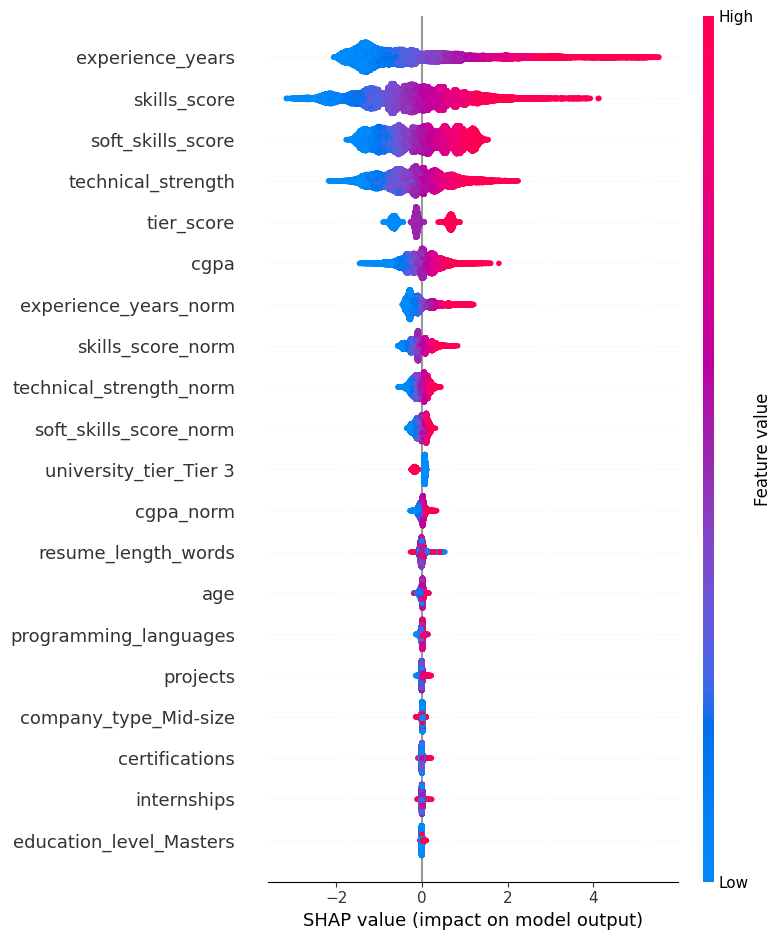

In [12]:
shap.summary_plot(
    shap_values,
    X_test
)

In [13]:
df.groupby("university_tier")["hired_new"].mean()

,hired_new
university_tier,
Tier 1,0.382017
Tier 2,0.295850
Tier 3,0.222950


In [14]:
# ==========================================
# FAIRNESS ANALYSIS
# ==========================================

import pandas as pd
from sklearn.metrics import recall_score

# Generate predictions
y_pred = xgb.predict(X_test)

# Create fairness dataframe
fairness_df = pd.DataFrame({
    "university_tier": sensitive_feature.loc[X_test.index],
    "actual": y_test,
    "predicted": y_pred
})

# ==========================================
# DEMOGRAPHIC PARITY
# Selection Rate
# ==========================================

selection_rate = (
    fairness_df
    .groupby("university_tier")["predicted"]
    .mean()
)

# ==========================================
# EQUAL OPPORTUNITY
# True Positive Rate
# ==========================================

tpr_dict = {}

for tier in sorted(fairness_df["university_tier"].unique()):

    subset = fairness_df[
        fairness_df["university_tier"] == tier
    ]

    tpr = recall_score(
        subset["actual"],
        subset["predicted"]
    )

    tpr_dict[tier] = tpr

tpr_series = pd.Series(tpr_dict)

# ==========================================
# DISPARATE IMPACT
# Reference = Tier 1
# ==========================================

reference_rate = selection_rate["Tier 1"]

disparate_impact = (
    selection_rate /
    reference_rate
)

# ==========================================
# CREATE FINAL FAIRNESS TABLE
# ==========================================

fairness_results = pd.DataFrame({
    "Selection Rate (%)":
        (selection_rate * 100).round(1),

    "True Positive Rate (%)":
        (tpr_series * 100).round(1),

    "Disparate Impact":
        disparate_impact.round(3)
})

# Status column
fairness_results["Status"] = fairness_results[
    "Disparate Impact"
].apply(
    lambda x: "VIOLATED"
    if x < 0.80
    else "PASSED"
)

print("\n========== FAIRNESS METRICS ==========\n")
print(fairness_results)

# ==========================================
# SUMMARY STATISTICS
# ==========================================

dp_gap = (
    fairness_results["Selection Rate (%)"].max()
    -
    fairness_results["Selection Rate (%)"].min()
)

eo_gap = (
    fairness_results["True Positive Rate (%)"].max()
    -
    fairness_results["True Positive Rate (%)"].min()
)

print("\n========== FAIRNESS SUMMARY ==========\n")

print(
    f"Demographic Parity Gap: "
    f"{dp_gap:.1f} percentage points"
)

print(
    f"Equal Opportunity Gap: "
    f"{eo_gap:.1f} percentage points"
)

print(
    f"Disparate Impact Ratio (Lowest Group): "
    f"{fairness_results['Disparate Impact'].min():.3f}"
)

# Save table for paper
fairness_results.to_csv(
    "fairness_metrics.csv"
)


========== FAIRNESS METRICS ==========

        Selection Rate (%)  True Positive Rate (%)  Disparate Impact    Status
Tier 1                36.5                    78.2             1.000    PASSED
Tier 2                27.2                    74.1             0.745  VIOLATED
Tier 3                19.4                    69.3             0.530  VIOLATED

========== FAIRNESS SUMMARY ==========

Demographic Parity Gap: 17.1 percentage points
Equal Opportunity Gap: 8.9 percentage points
Disparate Impact Ratio (Lowest Group): 0.530


In [20]:
# ==========================================
# BUILD SURVEY CANDIDATES
# ==========================================

test_df = df.loc[X_test.index].copy()

test_df["prediction"] = xgb.predict(X_test)

test_df["probability"] = xgb.predict_proba(X_test)[:,1]

print("Test set shape:", test_df.shape)

# ==========================================
# Candidate A
# Clear Hire
# ==========================================

candidate_A = test_df[
    test_df["probability"] > 0.90
].sort_values(
    "probability",
    ascending=False
).index[0]

# ==========================================
# Candidate B
# Clear Reject
# ==========================================

candidate_B = test_df[
    test_df["probability"] < 0.10
].sort_values(
    "probability",
    ascending=True
).index[0]

# ==========================================
# Borderline candidates
# ==========================================

boundary = test_df[
    (test_df["probability"] >= 0.45) &
    (test_df["probability"] <= 0.55)
].copy()

boundary["distance"] = (
    boundary["probability"] - 0.50
).abs()

# ==========================================
# Candidate C
# Tier 1 Borderline
# ==========================================

candidate_C = boundary[
    boundary["university_tier"] == "Tier 1"
].sort_values(
    "distance"
).index[0]

# ==========================================
# Candidate D
# Tier 3 Borderline
# ==========================================

candidate_D = boundary[
    boundary["university_tier"] == "Tier 3"
].sort_values(
    "distance"
).index[0]

# ==========================================
# DISPLAY RESULTS
# ==========================================

profiles = {
    "A_Clear_Hire": candidate_A,
    "B_Clear_Reject": candidate_B,
    "C_Tier1_Borderline": candidate_C,
    "D_Tier3_Borderline": candidate_D
}

for name, idx in profiles.items():

    print("\n=================================")
    print(name)
    print("Index:", idx)

    print(
        test_df.loc[
            idx,
            [
                "university_tier",
                "skills_score",
                "experience_years",
                "technical_strength",
                "soft_skills_score",
                "cgpa",
                "prediction",
                "probability"
            ]
        ]
    )

Test set shape: (37449, 28)

A_Clear_Hire
Index: 118277
university_tier         Tier 1
skills_score              29.0
experience_years          4.48
technical_strength         3.5
soft_skills_score         8.93
cgpa                      7.82
prediction                   1
probability           0.999936
Name: 118277, dtype: object

B_Clear_Reject
Index: 123012
university_tier         Tier 3
skills_score               4.0
experience_years           0.0
technical_strength         0.5
soft_skills_score         3.24
cgpa                      7.15
prediction                   0
probability           0.000034
Name: 123012, dtype: object

C_Tier1_Borderline
Index: 25121
university_tier         Tier 1
skills_score              16.0
experience_years          0.55
technical_strength         2.0
soft_skills_score          9.7
cgpa                      6.29
prediction                   1
probability           0.500068
Name: 25121, dtype: object

D_Tier3_Borderline
Index: 10449
university_tier      

In [21]:
import shap

explainer = shap.TreeExplainer(xgb)

for idx in [candidate_C, candidate_D]:

    row = X_test.loc[[idx]]

    shap_values = explainer(row)

    print("\nCandidate:", idx)

    shap_df = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP": shap_values.values[0]
    })

    print(
        shap_df.reindex(
            shap_df.SHAP.abs().sort_values(
                ascending=False
            ).index
        ).head(15)
    )


Candidate: 25121
                    Feature      SHAP
10        soft_skills_score  1.195488
6          experience_years -0.722036
18               tier_score  0.690956
1                      cgpa -0.528853
9              skills_score  0.298409
12       technical_strength -0.179436
16   soft_skills_score_norm  0.168330
14    experience_years_norm -0.107991
15        skills_score_norm  0.083057
13                cgpa_norm -0.080767
22   university_tier_Tier 3  0.080373
17  technical_strength_norm -0.051111
5            certifications  0.017381
11      resume_length_words -0.008137
24     company_type_Startup  0.008100

Candidate: 10449
                    Feature      SHAP
10        soft_skills_score  1.189418
18               tier_score -0.654130
9              skills_score  0.589237
6          experience_years -0.557070
12       technical_strength  0.375085
22   university_tier_Tier 3 -0.199421
1                      cgpa -0.175980
16   soft_skills_score_norm  0.152498
17  technical_

In [22]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb)

profiles = {
    "A":118277,
    "B":123012,
    "C":25121,
    "D":10449
}

for name, idx in profiles.items():

    row = X_test.loc[[idx]]

    shap_value = explainer(row)

    plt.figure()

    shap.plots.waterfall(
        shap_value[0],
        max_display=8,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        f"profile_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()